# Interpreting Nori on Credit Defaults

**Nori** (Synthefy's tabular foundation model) is a black box on its own, but it predicts
accurately and separates each feature's contribution cleanly — so we can *extract* its
reasoning. This self-contained notebook does that on the public UCI
[*Default of Credit Card Clients*](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)
dataset, in three steps:

1. **Feature importance** — which features drive default, read straight off Nori's predictions.
2. **Accuracy vs. number of features** — how few of them Nori needs to keep most of its accuracy.
3. **A glass-box model** — distil those features into an Explainable Boosting Machine you can
   read end to end, and check what it costs in accuracy.

All three come from a single `NoriInterpreter().fit(X, y)` call. Everything runs locally (the
dataset downloads fresh below); no API key.


## Setup

```bash
pip install "synthefy-nori[explainability]" ucimlrepo
```

Nori's weights download from Hugging Face on first use; a GPU is recommended but not required.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from ucimlrepo import fetch_ucirepo

from synthefy_nori.explainability import NoriInterpreter

# friendly labels for the credit features
LABELS = {
    "PAY_0": "Repay status (latest)", "PAY_2": "Repay status (−1 mo)",
    "PAY_3": "Repay status (−2 mo)", "PAY_4": "Repay status (−3 mo)",
    "PAY_5": "Repay status (−4 mo)", "PAY_6": "Repay status (−5 mo)",
    "LIMIT_BAL": "Credit limit", "BILL_AMT1": "Bill amount (latest)",
    "PAY_AMT1": "Payment amt (latest)", "AGE": "Age", "SEX": "Sex",
    "EDUCATION": "Education", "MARRIAGE": "Marriage",
}
ORANGE, ORANGE_DARK, INK, MUTED = "#F97316", "#7C2D12", "#111827", "#6B7280"
label = lambda n: LABELS.get(n, n)

## Load the data

The whole table goes to `NoriInterpreter`, which owns its own stratified **70/30** split — so
there is no split to get wrong here.


In [2]:
ds = fetch_ucirepo(id=350)                          # UCI Default of Credit Card Clients
X = ds.data.features.copy()
rename = {r["name"]: r["description"] for _, r in ds.variables.iterrows()
          if r["name"] in X.columns and isinstance(r["description"], str)}   # X1..X23 -> real names
X = X.rename(columns=rename)
y = ds.data.targets.iloc[:, 0].to_numpy().astype(int)
names = list(X.columns)
print(f"rows={len(X)}  features={X.shape[1]}  default rate={y.mean():.3f}")

rows=30000  features=23  default rate=0.221


## One call does all three steps

`fit` splits the table, ranks every feature by permutation importance (shuffle one raw column
of held-out rows, re-predict with the deployed model, keep the drop in AUC), prunes to the
fewest features that retain **95%** of Nori's skill, distils a glass-box EBM on exactly those,
and renders the model diagram — storing each artifact on the estimator.

By default importance is measured on the held-out split, which is the post-hoc reading: it
describes the model you would actually ship. One consequence to know is that the sweep stops at
the first feature count clearing the 95% bar, so `selection_score_` is that criterion's value
rather than an independent estimate. Pass `use_test=False` if you need every number to be a
clean held-out estimate.


In [3]:
interp = NoriInterpreter(model="nori-6m", target_name="default").fit(X, y)

s = interp.summary()
print(f"task={s['task']}  metric={s['metric']}")
print(f"Nori on all {s['n_features']} features : {s['nori_full']:.4f}")
print(f"kept {s['n_selected']}/{s['n_features']} features           : {s['nori_selected']:.4f}")
print(f"glass-box EBM on those          : {s['ebm_selected']:.4f}")
print(f"glass-box EBM on all features   : {s['ebm_full']:.4f}")
print("\ntop features:", [label(f) for f in s["top_features"]])

task=classification  metric=roc_auc
Nori on all 23 features : 0.7746
kept 7/23 features           : 0.7629
glass-box EBM on those          : 0.7635
glass-box EBM on all features   : 0.7724

top features: ['Repay status (latest)', 'Credit limit', 'Repay status (−1 mo)', 'Payment amt (latest)', 'Repay status (−2 mo)', 'Repay status (−4 mo)', 'PAY_AMT3']


## 1. What drives Nori's predictions

The drop in AUC when a column is shuffled is Nori's reliance on that feature — measured through
its full internal preprocessing, on the model as deployed.

Read the tail with care: everything below the first few sits near zero, and at that magnitude
the ordering is not stable across runs or splits.


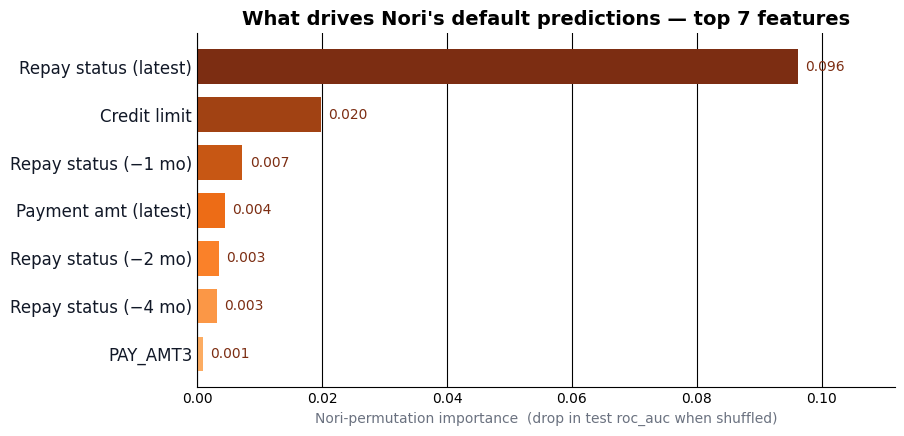

In [4]:
top = 7
items = interp.importance_ranking_[:top]
labels = [label(e["feature"]) for e in items]
vals = [e["importance"] for e in items]
ramp = LinearSegmentedColormap.from_list("s", [ORANGE_DARK, ORANGE, "#FDBA74"])
colors = [ramp(i / (top - 1) * 0.9) for i in range(top)]     # darkest = most important

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(range(top), vals, color=colors, height=0.72)
ax.set_yticks(range(top)); ax.set_yticklabels(labels, color=INK, fontsize=12); ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v + max(vals) * 0.012, i, f"{v:.3f}", va="center", fontsize=10, color=ORANGE_DARK)
ax.set_xlabel(f"Nori-permutation importance  (drop in test {interp.metric_} when shuffled)", color=MUTED)
ax.set_title("What drives Nori's default predictions — top 7 features", fontsize=14, weight="bold")
ax.set_xlim(0, max(vals) * 1.16)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.tick_params(length=0); ax.grid(axis="x", color="#00000018", lw=.8); ax.set_axisbelow(True)
plt.show()

### Do the demographics matter?

Worth checking explicitly, since it is the question a credit reviewer will ask.


In [5]:
demo = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
rank = {e["feature"]: (i + 1, e["importance"]) for i, e in enumerate(interp.importance_ranking_)}
top_imp = interp.importance_ranking_[0]
for f in demo:
    if f in rank:
        r, v = rank[f]
        print(f"{label(f):<24s} rank {r:>2}/{len(names)}   importance {v:+.5f}"
              f"   ({v / top_imp['importance']:.1%} of {label(top_imp['feature'])})")
print(f"\nselected: {[label(f) for f in interp.selected_features_]}")

Sex                      rank 15/23   importance -0.00031   (-0.3% of Repay status (latest))
Education                rank 12/23   importance +0.00005   (0.1% of Repay status (latest))
Marriage                 rank 10/23   importance +0.00031   (0.3% of Repay status (latest))
Age                      rank  9/23   importance +0.00039   (0.4% of Repay status (latest))

selected: ['Repay status (latest)', 'Credit limit', 'Repay status (−1 mo)', 'Payment amt (latest)', 'Repay status (−2 mo)', 'Repay status (−4 mo)', 'PAY_AMT3']


## 2. Accuracy vs. number of features

`sweep_` is the search the pruner actually walked: each candidate feature count and the skill it
reached, stopping at the first one that cleared the target.


top  2/23 feats  roc_auc=0.7343  (85% of full)
top  3/23 feats  roc_auc=0.7337  (85% of full)
top  4/23 feats  roc_auc=0.7420  (88% of full)
top  5/23 feats  roc_auc=0.7554  (93% of full)
top  7/23 feats  roc_auc=0.7629  (96% of full)


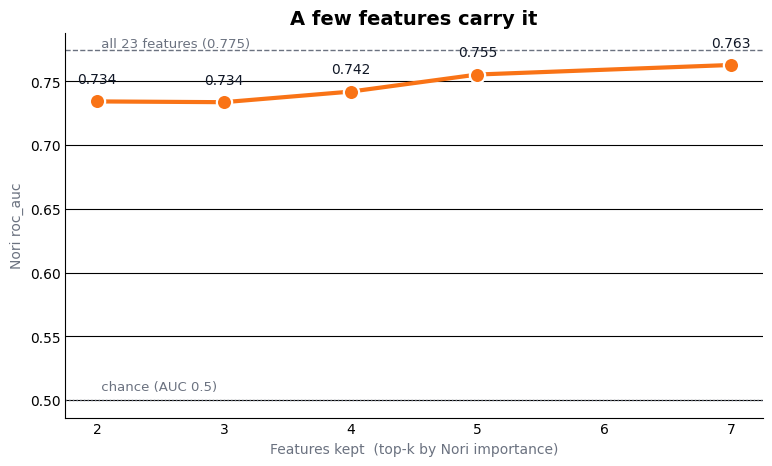

In [6]:
rows = interp.sweep_
full = interp.selection_full_score_
for r in rows:
    frac = 100 * (r[interp.metric_] - 0.5) / (full - 0.5)     # % of full skill above chance
    print(f"top {r['k']:>2}/{len(names)} feats  {interp.metric_}={r[interp.metric_]:.4f}  ({frac:.0f}% of full)")

xs = [r["k"] for r in rows]; ys = [r[interp.metric_] for r in rows]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, ys, "-o", color=ORANGE, markeredgecolor="white", markeredgewidth=1.6, lw=3, ms=11)
ax.axhline(full, color=MUTED, ls="--", lw=1)
ax.text(xs[0], full, f" all {len(names)} features ({full:.3f})", va="bottom", fontsize=9.5, color=MUTED)
ax.axhline(0.5, color=MUTED, ls=":", lw=1)
ax.text(xs[0], 0.505, " chance (AUC 0.5)", va="bottom", fontsize=9.5, color=MUTED)
for r in rows:
    ax.annotate(f"{r[interp.metric_]:.3f}", (r["k"], r[interp.metric_]), textcoords="offset points",
                xytext=(0, 13), ha="center", fontsize=10, color=INK)
ax.set_xlabel("Features kept  (top-k by Nori importance)", color=MUTED)
ax.set_ylabel(f"Nori {interp.metric_}", color=MUTED)
ax.set_title("A few features carry it", fontsize=14, weight="bold")
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.tick_params(length=0); ax.grid(axis="y", color="#00000018", lw=.8); ax.set_axisbelow(True)
plt.show()

## 3. The glass-box model

The EBM is a GA²M: `prediction = intercept + Σ fⱼ(xⱼ) + Σ fⱼₖ(xⱼ,xₖ)`, where every `f` is a
binned lookup table — so the per-bin scores *are* the weights, and the whole model is readable.

The diagram below is rendered during `fit`. It draws each kept feature's shape function with a
grey data-density histogram (so extrapolation regions are visible), the strongest pairwise
interactions, and the Σ → σ → ŷ chain. Note the heatmap subtitle: only the strongest few
interactions are drawn, but every one of them is in the model and in Σ.


glass-box EBM (7 features): roc_auc = 0.7635
Nori on all 23 features       : roc_auc = 0.7746
cost of the glass-box              : +0.0111

serialised model: 7 shape functions + 10 pairwise interactions


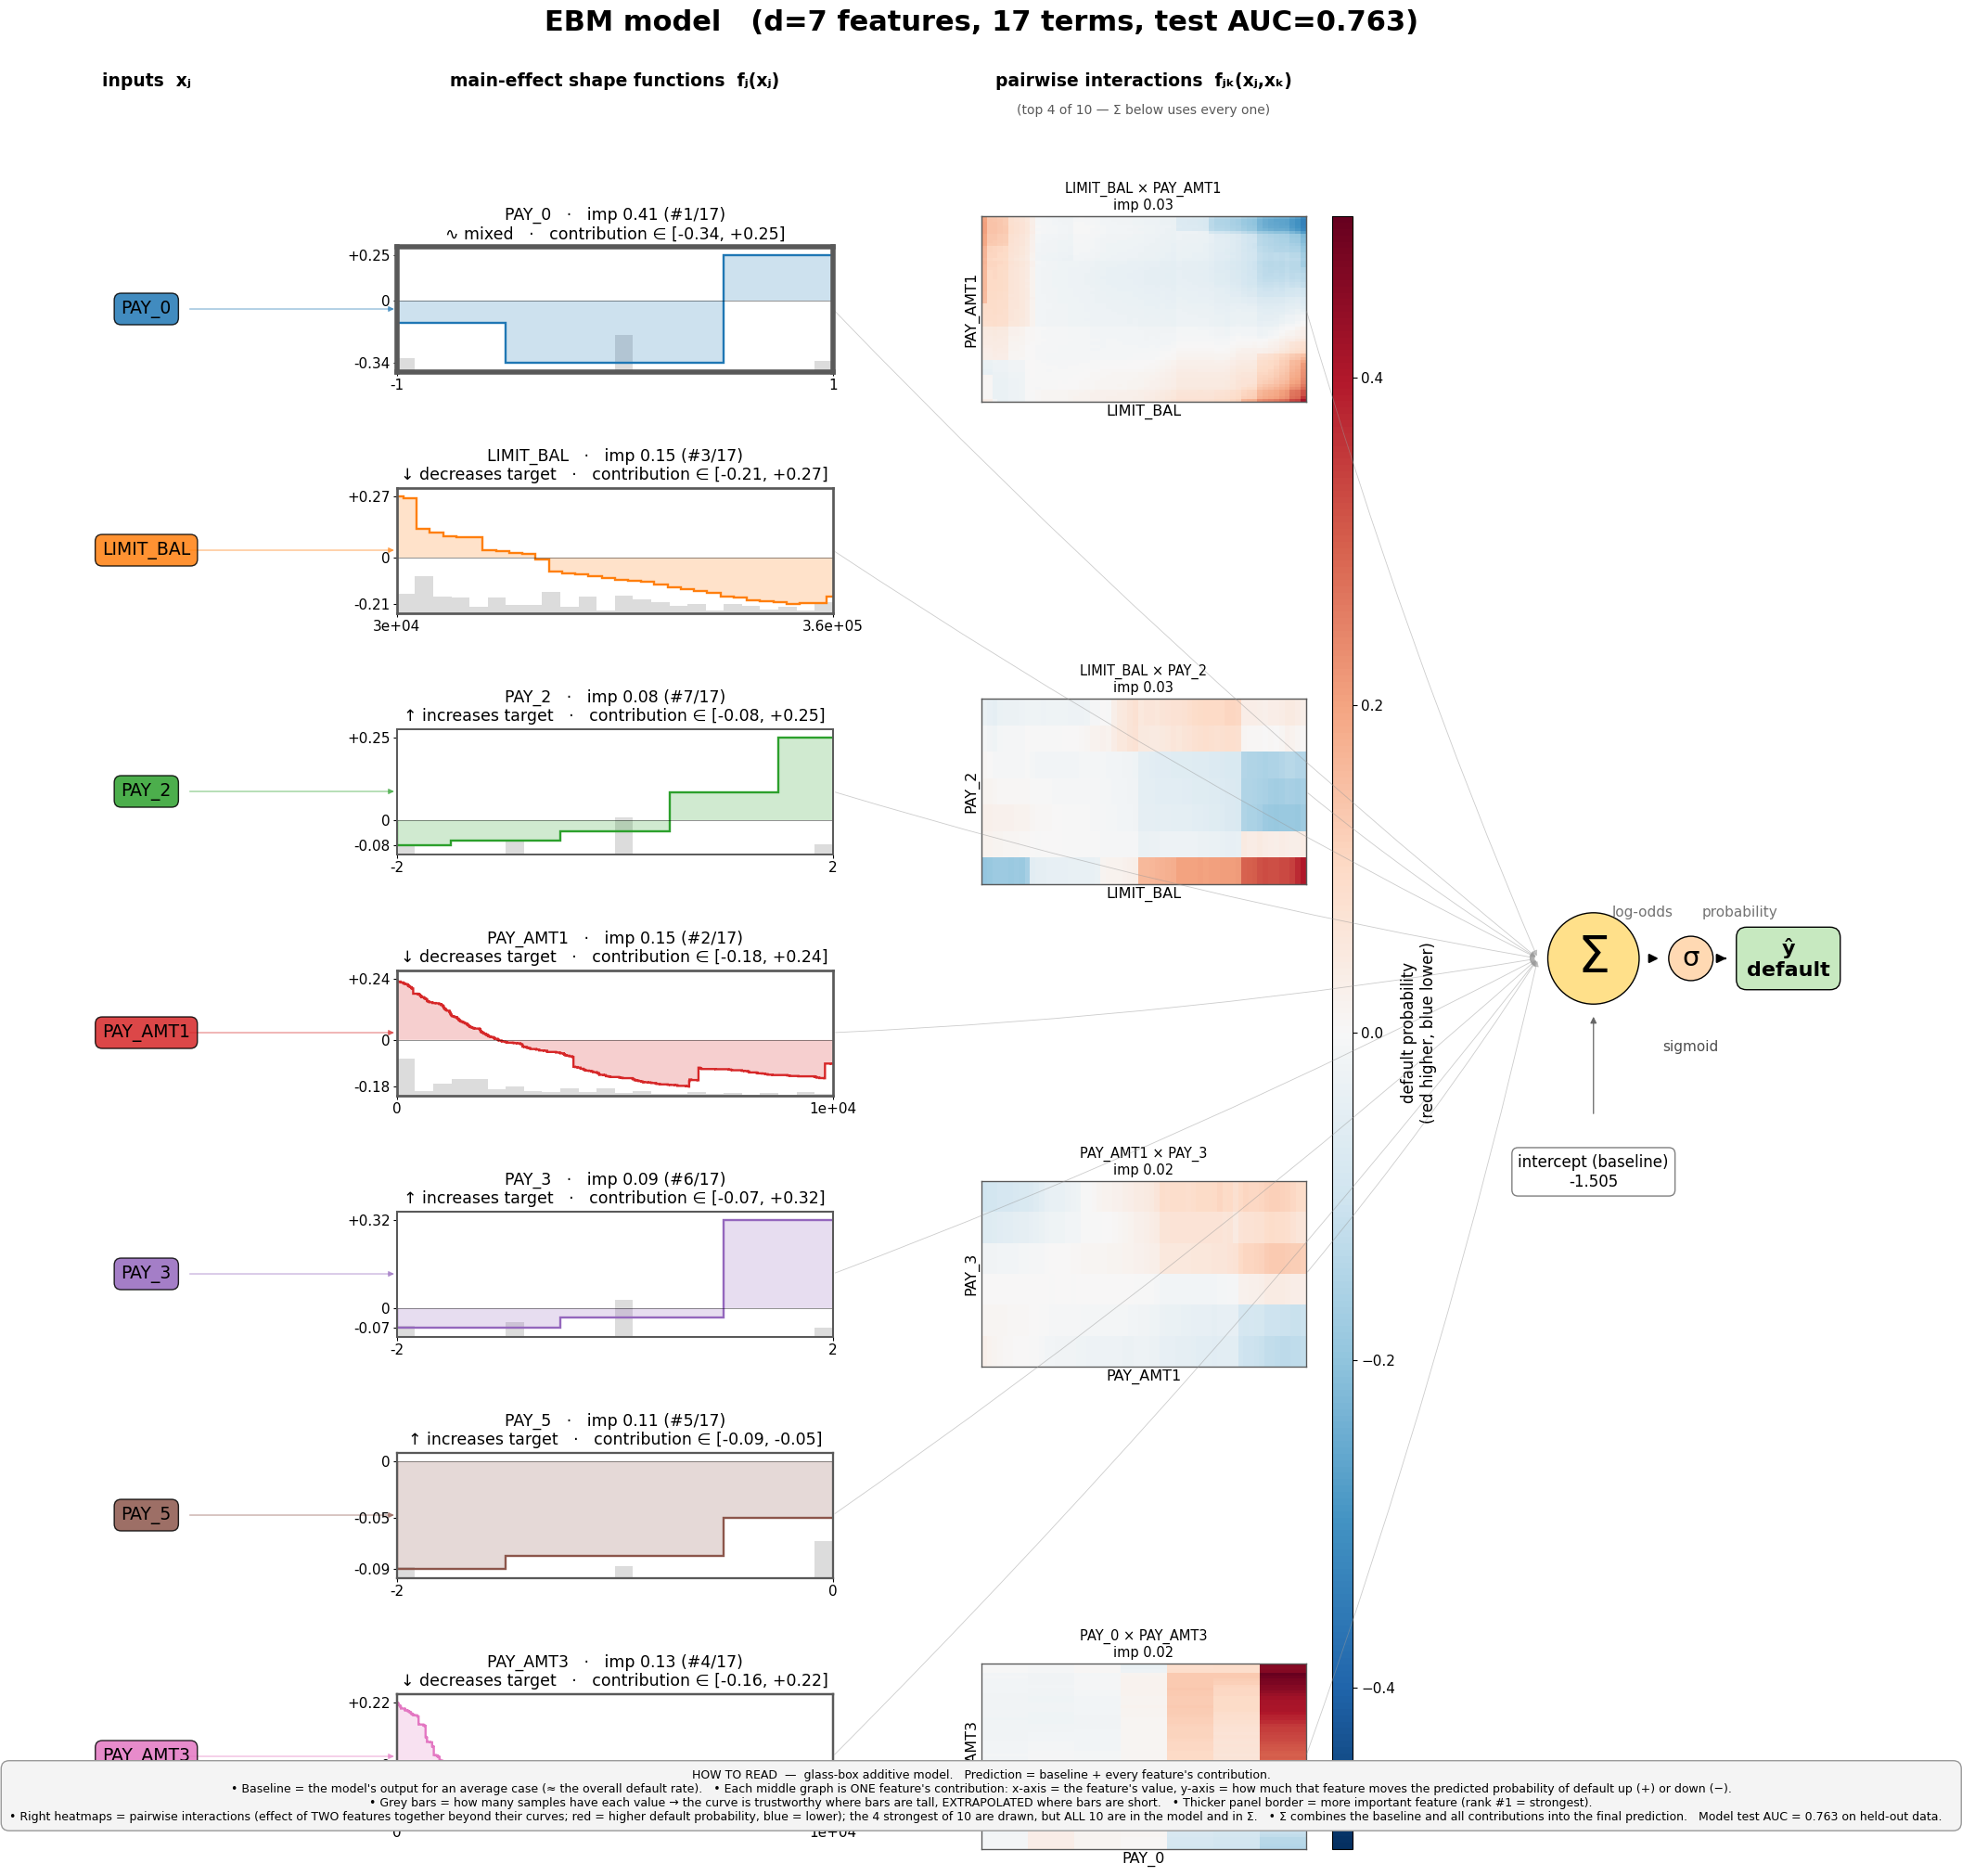

In [7]:
print(f"glass-box EBM ({interp.n_selected_} features): {interp.metric_} = {interp.ebm_score_:.4f}")
print(f"Nori on all {len(names)} features       : {interp.metric_} = {interp.nori_full_score_:.4f}")
print(f"cost of the glass-box              : {interp.nori_full_score_ - interp.ebm_score_:+.4f}")
n_shape = len(interp.ebm_model_["shape_functions"])
n_inter = len(interp.ebm_model_.get("interactions", []))
print(f"\nserialised model: {n_shape} shape functions + {n_inter} pairwise interactions")
interp.model_figure_

### The model is a shippable object

`interp.ebm_` is a fitted EBM: pickle it, score with it, or read its weights as plain JSON via
`interp.ebm_model_`. Nori is no longer in the loop at inference time.


In [8]:
probs = interp.predict_proba(X.to_numpy(np.float32)[:5])[:, 1]
print("predicted default probability, first 5 customers:", np.round(probs, 4))
print("predicted labels (the caller's own label space):", interp.predict(X.to_numpy(np.float32)[:5]))

first = interp.ebm_model_["shape_functions"][0]
print(f"\nshape function for {label(first['feature'])}: {len(first['scores'])} bins, "
      f"direction={first['direction']}")

predicted default probability, first 5 customers: [0.6719 0.245  0.143  0.1453 0.1442]
predicted labels (the caller's own label space): [1 0 0 0 0]

shape function for Repay status (latest): 11 bins, direction=non-monotone


## Want to try this on your own data?

This ran entirely locally on a public dataset. To try Nori's interpretability on **your** data, **contact us at [insights@synthefy.com](mailto:insights@synthefy.com)**.

- Docs: [docs.synthefy.com/nori](https://docs.synthefy.com/nori)
- GitHub: [github.com/Synthefy/synthefy-nori](https://github.com/Synthefy/synthefy-nori)